# 10 · Evaluación de Baselines — Sprint 3
**Proyecto:** Detección de Sitios Web Fraudulentos (Phishing)  
**Sprint 3 — PB-11:** Evaluación con métricas de clasificación y cross-validation

---

## Objetivo

Evaluar cada modelo baseline con métricas robustas (F1, AUC-ROC, Recall, Precision)
usando `StratifiedKFold`, y generar visualizaciones diagnósticas: curvas ROC,
matrices de confusión y classification reports.

## Justificación de métricas principales

En detección de phishing:
- **Recall** — prioridad alta: un falso negativo (phishing no detectado) tiene alto costo para el usuario.
- **F1-Score** — métrica principal: equilibrio entre precision y recall, robusta ante clases desbalanceadas.
- **AUC-ROC** — capacidad discriminatoria general del modelo.
- **Accuracy** — referencia, no usada para decisiones (puede ser engañosa con desbalance).

> Esta decisión de métricas está alineada con los criterios de éxito definidos en `01_business.ipynb` (Sprint 1).


## 1. Imports y carga de modelos

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate

from src.models import get_baseline_models, load_model

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print('✓ Librerías cargadas.')

✓ Librerías cargadas.


## 2. Cargar datos y modelos

In [2]:
TARGET_COL = 'Result'

# Train (crudos, con SMOTE)
train_df = pd.read_csv('../data/processed/train.csv')
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

# Test (crudos)
test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Distribución y_train: {dict(y_train.value_counts().sort_index())}')
print(f'Distribución y_test:  {dict(y_test.value_counts().sort_index())}')

Train: (4830, 37) | Test: (1170, 37)
Distribución y_train: {-1: np.int64(2415), 1: np.int64(2415)}
Distribución y_test:  {-1: np.int64(604), 1: np.int64(566)}


In [3]:
# Cargar todos los modelos entrenados en 09_baseline_models.ipynb
model_names = list(get_baseline_models().keys())

models = {}
for name in model_names:
    short = name.lower().replace(' ', '_')
    try:
        models[name] = load_model(short, model_dir='../models')
    except FileNotFoundError:
        print(f'⚠️  Modelo no encontrado: {name}. Ejecutar primero 09_baseline_models.ipynb')

print(f'\n✅ Modelos cargados: {list(models.keys())}')

[load_model] 'logistic_regression' cargado desde '../models\baseline_logistic_regression.pkl'.
[load_model] 'decision_tree' cargado desde '../models\baseline_decision_tree.pkl'.
[load_model] 'random_forest' cargado desde '../models\baseline_random_forest.pkl'.
[load_model] 'gradient_boosting' cargado desde '../models\baseline_gradient_boosting.pkl'.
[load_model] 'svm' cargado desde '../models\baseline_svm.pkl'.
[load_model] 'knn' cargado desde '../models\baseline_knn.pkl'.
[load_model] 'naive_bayes' cargado desde '../models\baseline_naive_bayes.pkl'.

✅ Modelos cargados: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'KNN', 'Naive Bayes']


## 3. Cross-validation estratificada (5-fold)

Se usa `StratifiedKFold` para preservar la proporción de clases en cada fold.
Se evalúan 5 métricas en train y test para detectar overfitting.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy':  'accuracy',
    'f1':        'f1',
    'precision': 'precision',
    'recall':    'recall',
    'roc_auc':   'roc_auc',
}

cv_results = {}
for name, pipe in models.items():
    print(f'CV: {name}...')
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring=SCORING, return_train_score=True, n_jobs=-1)
    cv_results[name] = res
    print(f'  F1={res["test_f1"].mean():.4f} | AUC={res["test_roc_auc"].mean():.4f} | Recall={res["test_recall"].mean():.4f}')

print('\n✅ Cross-validation completa.')

CV: Logistic Regression...
  F1=0.9350 | AUC=0.9839 | Recall=0.9449
CV: Decision Tree...
  F1=0.9153 | AUC=0.9194 | Recall=0.9135
CV: Random Forest...
  F1=0.9419 | AUC=0.9861 | Recall=0.9507
CV: Gradient Boosting...
  F1=0.9417 | AUC=0.9881 | Recall=0.9503
CV: SVM...
  F1=0.9422 | AUC=0.9843 | Recall=0.9553
CV: KNN...
  F1=0.9298 | AUC=0.9777 | Recall=0.9255
CV: Naive Bayes...
  F1=0.5740 | AUC=0.9556 | Recall=0.4029

✅ Cross-validation completa.


## 4. Classification Report por modelo

In [5]:
class_names = ['Phishing (-1)', 'Legítimo (1)']

print('=' * 70)
for name, pipe in models.items():
    y_pred = pipe.predict(X_test)
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=class_names))
    print('=' * 70)


--- Logistic Regression ---
               precision    recall  f1-score   support

Phishing (-1)       0.94      0.92      0.93       604
 Legítimo (1)       0.92      0.94      0.93       566

     accuracy                           0.93      1170
    macro avg       0.93      0.93      0.93      1170
 weighted avg       0.93      0.93      0.93      1170


--- Decision Tree ---
               precision    recall  f1-score   support

Phishing (-1)       0.92      0.92      0.92       604
 Legítimo (1)       0.92      0.92      0.92       566

     accuracy                           0.92      1170
    macro avg       0.92      0.92      0.92      1170
 weighted avg       0.92      0.92      0.92      1170


--- Random Forest ---
               precision    recall  f1-score   support

Phishing (-1)       0.95      0.94      0.94       604
 Legítimo (1)       0.94      0.94      0.94       566

     accuracy                           0.94      1170
    macro avg       0.94      0.94   

## 5. Matrices de confusión

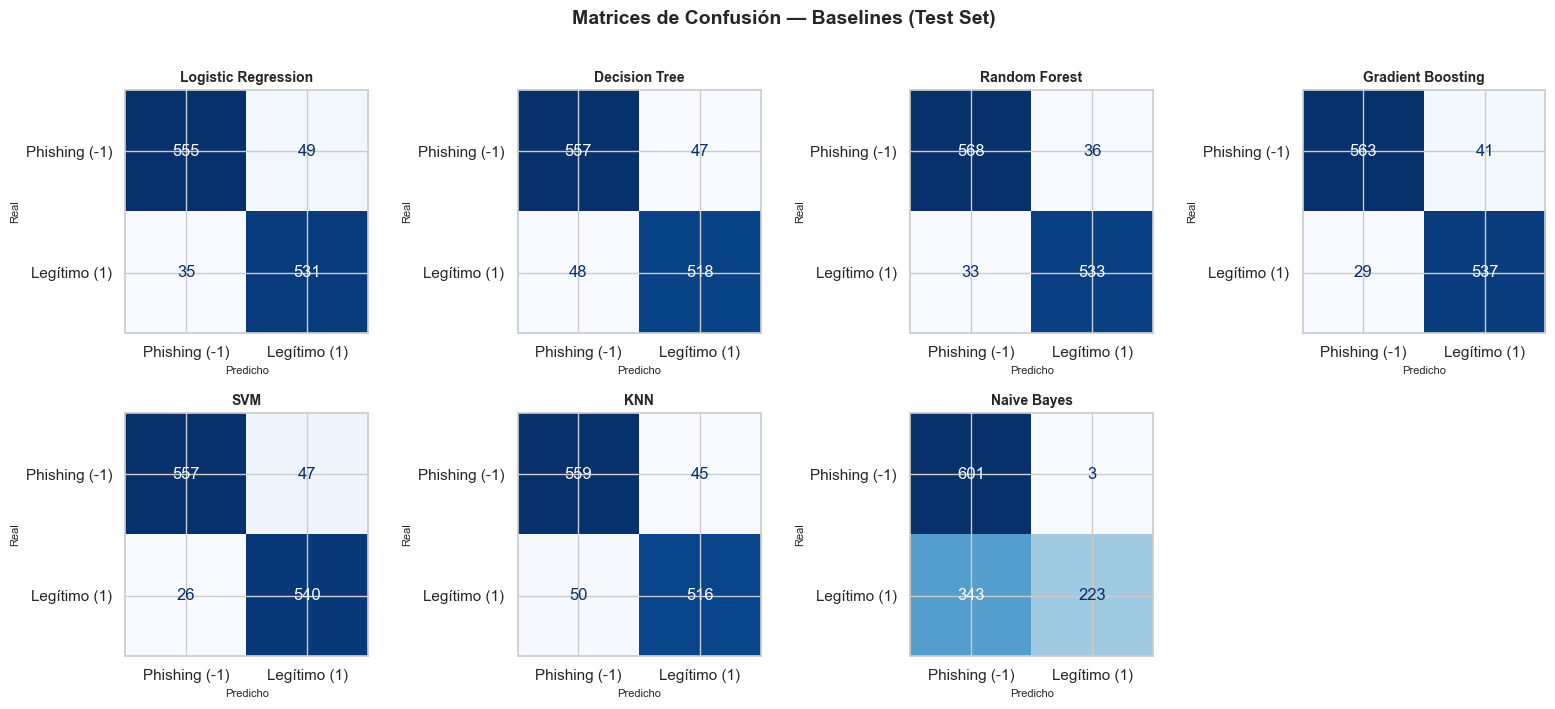

In [6]:
n = len(models)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.ravel()

for i, (name, pipe) in enumerate(models.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test,
        display_labels=class_names,
        ax=axes[i], cmap='Blues', colorbar=False
    )
    axes[i].set_title(name, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicho', fontsize=8)
    axes[i].set_ylabel('Real', fontsize=8)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de Confusión — Baselines (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Curvas ROC

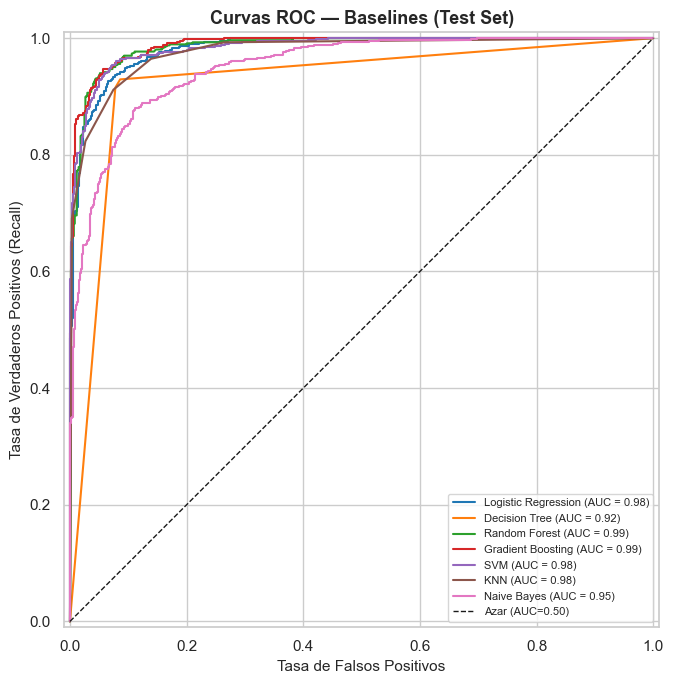

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

palette = plt.cm.tab10.colors
for i, (name, pipe) in enumerate(models.items()):
    RocCurveDisplay.from_estimator(
        pipe, X_test, y_test,
        name=name, ax=ax, color=palette[i]
    )

ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.50)', linewidth=1)
ax.set_title('Curvas ROC — Baselines (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('../models/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Curvas Precision-Recall

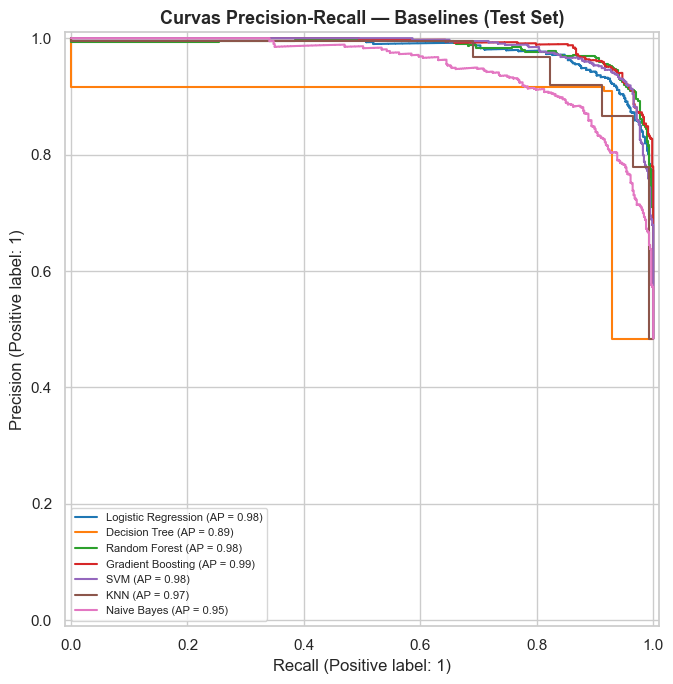

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

for i, (name, pipe) in enumerate(models.items()):
    PrecisionRecallDisplay.from_estimator(
        pipe, X_test, y_test,
        name=name, ax=ax, color=palette[i]
    )

ax.set_title('Curvas Precision-Recall — Baselines (Test Set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig('../models/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Detección de overfitting y underfitting

Se compara F1 en train vs. test (CV):
- **Overfitting:** gap > 0.10 (train mucho mejor que test)
- **Underfitting:** F1 test < 0.70 (rendimiento pobre en ambos)

In [9]:
print(f'{'Modelo':30s} | {'Train F1':>9} | {'Test F1':>9} | {'Gap':>7} | Diagnóstico')
print('-' * 75)

for name, res in cv_results.items():
    train_f1 = res['train_f1'].mean()
    test_f1  = res['test_f1'].mean()
    gap = train_f1 - test_f1

    if gap > 0.10:
        diag = '⚠️  Overfitting'
    elif test_f1 < 0.70:
        diag = '⬇️  Underfitting'
    else:
        diag = '✅ OK'

    print(f'{name:30s} | {train_f1:9.4f} | {test_f1:9.4f} | {gap:7.4f} | {diag}')

Modelo                         |  Train F1 |   Test F1 |     Gap | Diagnóstico
---------------------------------------------------------------------------
Logistic Regression            |    0.9370 |    0.9350 |  0.0020 | ✅ OK
Decision Tree                  |    0.9929 |    0.9153 |  0.0776 | ✅ OK
Random Forest                  |    0.9930 |    0.9419 |  0.0510 | ✅ OK
Gradient Boosting              |    0.9522 |    0.9417 |  0.0105 | ✅ OK
SVM                            |    0.9549 |    0.9422 |  0.0127 | ✅ OK
KNN                            |    0.9564 |    0.9298 |  0.0265 | ✅ OK
Naive Bayes                    |    0.5732 |    0.5740 | -0.0007 | ⬇️  Underfitting


## 9. Resumen del notebook — PB-11

### Hallazgos principales

- **Métrica principal elegida:** F1-Score, por el costo asimétrico de falsos negativos en phishing.
- Las curvas ROC permiten seleccionar el umbral de clasificación óptimo en Sprint 4.
- Los modelos con alto Overfit_Gap serán candidatos a regularización en Sprint 4.
- Las matrices de confusión revelan el tipo de error predominante por modelo.

### Archivos generados

| Archivo | Descripción |
|---------|-------------|
| `models/confusion_matrices.png` | Matrices de confusión (test set) |
| `models/roc_curves.png` | Curvas ROC comparativas |
| `models/precision_recall_curves.png` | Curvas Precision-Recall |

### Siguiente paso

→ `11_model_comparison.ipynb` (PB-12): comparación final y selección de candidatos para Sprint 4.
